# 22DM015 Final Project — Financial PhraseBank

**Part 1 — Setting Up the Problem**

## 1a.‍ Bibliography & State of the Art

Our task is to classify financial sentences at the sentence level into either positive, negative, or neutral sentiments.‍ The dataset is the Financial PhraseBank introduced by [Malo et al.‍ (2014)](https://doi.org/10.48550/arXiv.1307.5336).‍ The data contains human-annotated short financial sentences drawn from news and company reports.‍ In addition to the data, the paper's contribution was analysis of financial news based on semantic orientation, whereas at the time much of the research in the domain was based on prior polarity of financial words.‍ 

We chose this dataset because an automated sentiment analysis for financial news can be useful as a fast early indicator for company or economic assessment, which is relevant in the fields of trading or risk assessment for example.‍ 

Along with the dataset, Malo et al.‍ also presented techniques to identify the overall direction of events affecting overall sentiment, and a linearized phrase-structure (LPS) model for detecting semantic orientation of financial and economic news text.‍ The techniques will be useful to understand our dataset and will be part of our guide in deriving our rules-based model.‍  

Recent improvements on the models are mainly with BERT as the baseline model and different improvement methods.‍ The performance of the two we found on the dataset where all annotators agree is in the table below, together with the original model performance.‍ 

| Model | Performance (Accuracy / F1) | Core Architecture |
|---|---|---|
| LPS - [Malo et al.‍ (2014)](https://doi.org/10.48550/arXiv.1307.5336) | 0.82–0.95 / 0.74–0.86 ¹ | linearized phrase-structure approach (lexicon + linguistic features) |
| FinBERT - [Araci (2019)](https://doi.org/10.48550/arXiv.1908.10063) | 0.97 / 0.95 ² | BERT fine-tuned on Financial PhraseBank |
| EnhancedFinSentiBert - [Sun et al.‍ (2025)](https://doi.org/10.1016/j.nlp.2025.100148) | - / 0.98 ³ | FinBERT + domain dictionaries + neutral feature extraction | 

<sub>¹ Malo et al.‍ reports F1 per sentiment so we put the range instead.‍ &nbsp;&nbsp; ² Araci reports macro F1.‍ &nbsp;&nbsp; ³ Sun et al.‍ report weighted F1.</sub>

For this project, the comparable SOTA is the model from Araci (2019) which is what we will use for Part 3.‍

References:
1.‍ Malo, P., Sinha, A., Korhonen, P., Wallenius, J., & Takala, P.‍ (2014).‍ Good debt or bad debt: Detecting semantic orientations in economic texts.‍ Journal of the Association for Information Science and Technology, 65(4), 782-796.‍ [https://doi.org/10.48550/arXiv.1307.5336](https://doi.org/10.48550/arXiv.1307.5336)
   
2.‍ Araci, D.‍ (2019).‍ FinBERT: Financial sentiment analysis with pre-trained language models.‍ arXiv preprint arXiv:1908.10063.‍ [https://doi.org/10.48550/arXiv.1908.10063](https://doi.org/10.48550/arXiv.1908.10063)
   
3.‍ Sun, Y., Yuan, H., & Xu, F.‍ (2025).‍ Financial sentiment analysis for pre-trained language models incorporating dictionary knowledge and neutral features.‍ Natural Language Processing, 4, 100148.‍ [https://doi.org/10.1016/j.nlp.2025.100148](https://doi.org/10.1016/j.nlp.2025.100148)

## Preparations

Note that we created the python module `data_utils` which has the helper function to load the data splits prepared by `dataprep_aug.ipynb`.‍ We also created the python module `eval_utils` which has helper functions to compute the usual performance metrics.‍ 

In [17]:
# watermark: AGLLM (AI-assisted content disclosure)
import os, sys

sys.path.append(os.path.abspath('..'))
import data_utils as du

# Global config, call from data_utils so consistent across notebooks
SEED = du.SEED
print(f"SEED: {SEED}")

import eval_utils as eu

import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

SEED: 618
Last run: 2026-06-16 19:15:10


## 1b.‍ Dataset Description

The dataset was constructed by collecting English news about all listed companies in OMX Helsinki.‍ The news was scraped from the LexisNexis database and a random subset of articles was selected to cover small and large companies, companies in different industries, and news from different sources.‍ From these articles they selected sentences containing words from a lexicon of financial words with inherent polarities, along with directional words that influence the polarities.‍ From here a subset of 5000 was chosen as representative of the entire database.‍ 

Each sentence was annotated by 5-8 people, with the instruction of considering the sentences "from the viewpoint of an investor only", which means according to its potential impact on stock price, and that the sentence should be judged based on the sentence alone, i.e.‍ no speculation on prior knowledge.‍ 

They released four versions of the dataset depending on the agreement of the annotators.‍ For this project, we selected the version where all annotators agree (`sentences_allagree` ) for simplicity.‍ This version has 2264 sentences in total, 303 (13.4%) negative sentences, 1391 (61.4%) neutral sentences, and 570 (25.2%) positive sentences.‍ The average length of the sentences is about 22 words, with the middle 50% of sentences between 15 and 28 words (the full range is 2 to 81 words).‍

We then split this data into train, validation, and test at 70-10-20 distribution.‍ We looked at the train split to further explore the data.‍ 

In [18]:
# watermark: AGLLM (AI-assisted content disclosure)
label_names = du.LABEL_NAMES
label_names

['negative', 'neutral', 'positive']

Last run: 2026-06-16 19:15:10


In [19]:
# watermark: AGLLM (AI-assisted content disclosure)
# Load the data splits
splits = du.load_splits()
train, val, test = splits['train'], splits['val'], splits['test']
full = pd.concat([train, val, test], ignore_index=True)
full.info();
full.head()

<class 'pandas.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          2264 non-null   int64
 1   text        2264 non-null   str  
 2   label       2264 non-null   int64
 3   label_name  2264 non-null   str  
dtypes: int64(2), str(2)
memory usage: 356.9 KB


,id,text,label,label_name
0,0,"According to Gran , the company has no plans t...",1,neutral
1,1,"For the last quarter of 2010 , Componenta 's n...",2,positive
2,2,"In the third quarter of 2010 , net sales incre...",2,positive
3,5,Finnish Talentum reports its operating profit ...,2,positive
4,6,Clothing retail chain Sepp+ñl+ñ 's sales incre...,2,positive


Last run: 2026-06-16 19:15:10


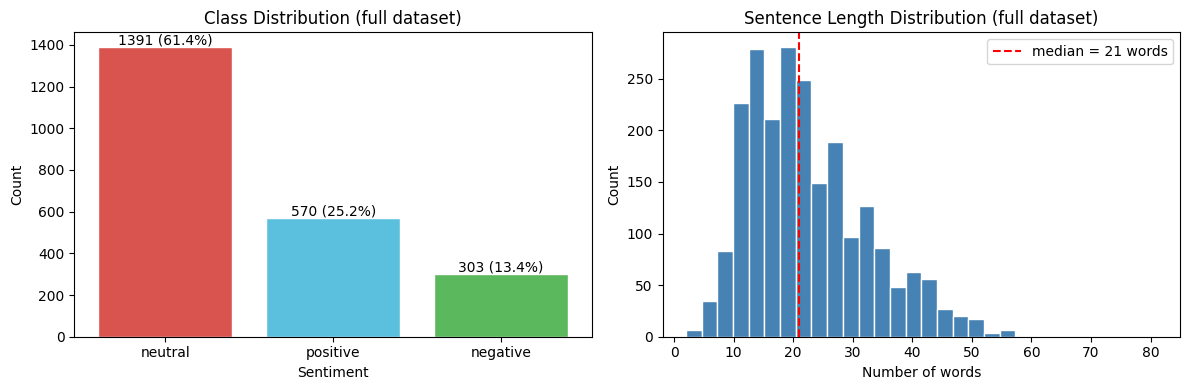

Last run: 2026-06-16 19:15:11


In [20]:
# watermark: AGLLM (AI-assisted content disclosure)
full = pd.concat([train, val, test], ignore_index=True)
full['n_words'] = full['text'].str.split().map(len)

vc = full['label_name'].value_counts()

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#d9534f', '#5bc0de', '#5cb85c']
bars = axes[0].bar(vc.index, vc.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (full dataset)');
axes[0].set_xlabel('Sentiment');
axes[0].set_ylabel('Count');
for bar, cnt in zip(bars, vc.values):
    pct = cnt / vc.sum()
    lbl = f'{cnt} ({pct:.1%})'
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 12, lbl, ha='center', fontsize=10)

axes[1].hist(full['n_words'], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(full['n_words'].median(), color='red', linestyle='--',
                label=f"median = {int(full['n_words'].median())} words")
axes[1].set_title('Sentence Length Distribution (full dataset)');
axes[1].set_xlabel('Number of words');
axes[1].set_ylabel('Count');
axes[1].legend();

plt.tight_layout()
plt.show()


## Exploratory Data Analysis

We focus on the train split as observations on this part will affect our methods for the modeling parts of the project.‍ 

=== Corpus statistics (train set) ===
Corpus length (total tokens)       : 28795
Unique vocabulary (types)          : 4378
Unique vocabulary excl. stopwords  : 4167



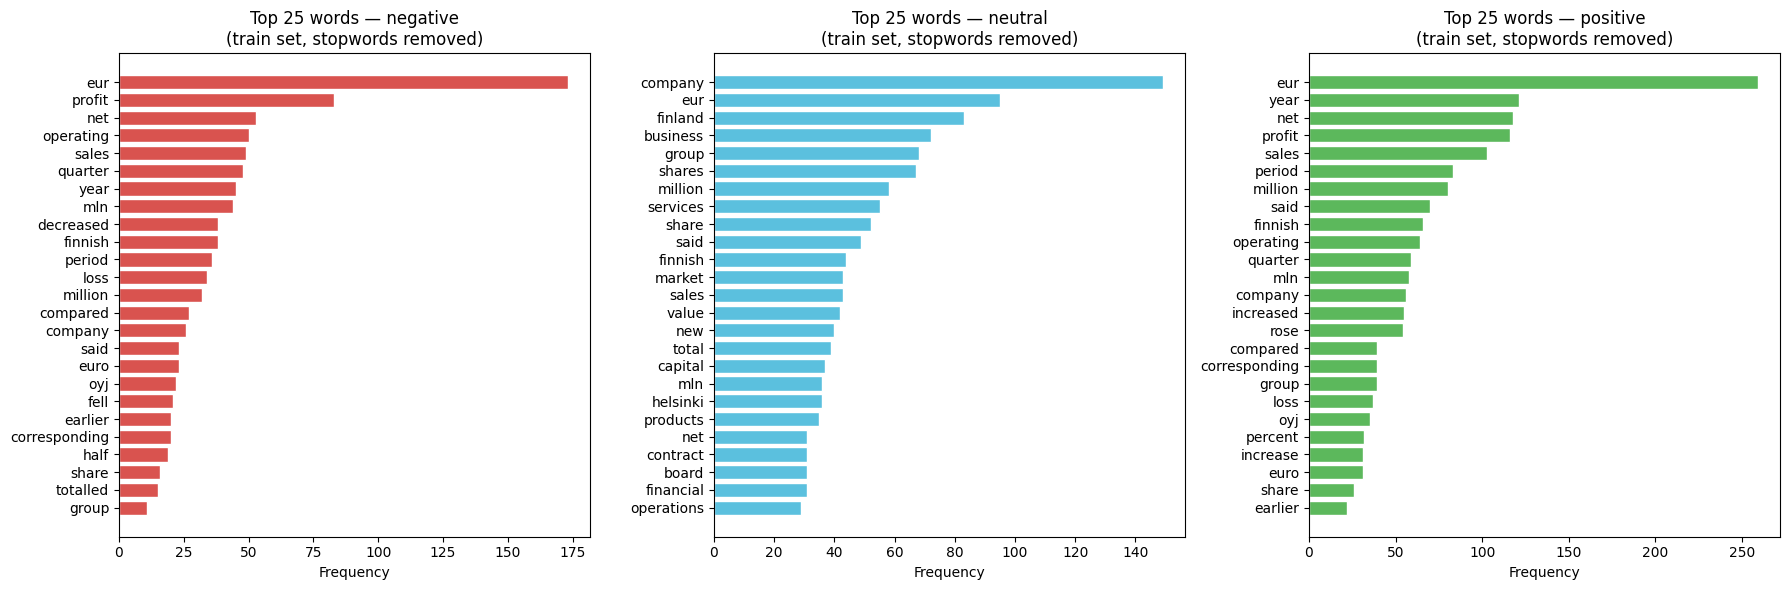

Last run: 2026-06-16 19:15:11


In [21]:
# watermark: AGLLM (AI-assisted content disclosure)
def top_words(df, label_name, top_n=25):
    tokens_all = []
    for text in df[df['label_name'] == label_name]['text']:
        tokens = re.findall(r'\b[a-z]+\b', text.lower())
        tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS and len(w) > 2]
        tokens_all.extend(tokens)
    return Counter(tokens_all).most_common(top_n)

neg_top = top_words(train, 'negative')
neu_top = top_words(train, 'neutral')
pos_top = top_words(train, 'positive')

# ---- Corpus statistics (train set) ----
# Tokenize the whole training corpus the same way as above (lowercase, alphabetic
# tokens). "Vocabulary" = distinct token types; the stopword-free count uses the same
# sklearn ENGLISH_STOP_WORDS list applied in top_words().
all_tokens = [w for text in train['text'] for w in re.findall(r'\b[a-z]+\b', text.lower())]
vocab = set(all_tokens)
vocab_no_stop = {w for w in vocab if w not in ENGLISH_STOP_WORDS}

print('=== Corpus statistics (train set) ===')
print(f'Corpus length (total tokens)       : {len(all_tokens)}')
print(f'Unique vocabulary (types)          : {len(vocab)}')
print(f'Unique vocabulary excl. stopwords  : {len(vocab_no_stop)}')
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (top, label, color) in zip(axes, [
    (neg_top, 'negative', '#d9534f'),
    (neu_top, 'neutral',  '#5bc0de'),
    (pos_top, 'positive', '#5cb85c'),
]):
    words, counts = zip(*top)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 25 words — {label}\n(train set, stopwords removed)')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

The charts show that some words are common in all three classes, like "eur", "year", "quarter", "mln", "period", which are measurements or units, and "company", "group", "board" which are references to the entity.‍ These do not carry sentiments.‍ 

We also see financial words that are inherently positive such as "profit" and "sales" but used in both negative and positive sentiment.‍ These words can switch in sentiment depending on the direction (as the paper has noted, but we need to see examples).‍ We also have inherently negative financial words such as "loss" which appears in both positive and negative.‍ Again, the sentiment might have switched depending on the directional word accompanying it.‍ 

We also have words that actually separate negative from positive and these are the directional words.‍ "decreased" shows up more in negative sentences, while "increased" and "rose" appear more in positive ones.‍

To confirm/expand we check on a few samples.‍

**Negative**

For statements 1-3, we have samples of financial words with inherent polarities.‍ Inherently positive financial words are "sales", "earnings", and "growth margin".‍ However, these were paired with the words "slowing", "fall", and "slowed down" which changed the polarity of the words.‍ Statements 4-5 are the same (by chance!), and used the inherently negative word "loss" which was strengthened by the direction "slipped".‍ 

In [22]:
# watermark: AGLLM (AI-assisted content disclosure)
label = label_names[0]
print(f"{label} \n")
for i in range(5):
    print(f"{i+1}. {train[train['label_name'] == label]['text'].iloc[i]} \n")

negative 

1. Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-date , gotta-have cars . 

2. Pharmaceuticals group Orion Corp reported a fall in its third-quarter earnings that were hit by larger expenditures on R&D and marketing . 

3. However , the growth margin slowed down due to the financial crisis . 

4. 2009 3 February 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR46m in the fourth quarter of 2009 from a year-earlier profit of EUR45m . 

5. ( ADPnews ) - Feb 3 , 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR 46 million ( USD 64.5 m ) in the fourth quarter of 2009 from a 

Last run: 2026-06-16 19:15:11



**Positive**

For sentences 1-5, we also get the positive financial words "sales" and "profit" which were also paired with directional words that strengthened the sentiment: "doubled", "increased", "rose".‍

In [23]:
# watermark: AGLLM (AI-assisted content disclosure)
label = label_names[2]
print(f"{label} \n")
for i in range(5):
    print(f"{i+1}. {train[train['label_name'] == label]['text'].iloc[i]} \n")

positive 

1. For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m . 

2. In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn . 

3. Finnish Talentum reports its operating profit increased to EUR 20.5 mn in 2005 from EUR 9.3 mn in 2004 , and net sales totaled EUR 103.3 mn , up from EUR 96.4 mn . 

4. Clothing retail chain Sepp+ñl+ñ 's sales increased by 8 % to EUR 155.2 mn , and operating profit rose to EUR 31.1 mn from EUR 17.1 mn in 2004 . 

5. Consolidated net sales increased 16 % to reach EUR74 .8 m , while operating profit amounted to EUR0 .9 m compared to a loss of EUR0 .7 m in the prior year period . 

Last run: 2026-06-16 19:15:11


**Neutral** 

For the neutral sentences, we don't see a sample of financial words with inherent polarities, only those that seem to be neutral such as "production", "turnover", "convertible notes", "investment", "capital".‍ It seems that these words are useful for sentiment when there is a direction involved.‍ For sentence 2, there is the use of direction "increase" but this is used together with "capital" which is neutral.‍ From the annotator's perspective, the entire sentiment is neutral.‍ 

In [24]:
# watermark: AGLLM (AI-assisted content disclosure)
label = label_names[1]
print(f"{label} \n")
for i in range(5):
    print(f"{i+1}. {train[train['label_name'] == label]['text'].iloc[i]} \n")

neutral 

1. According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing . 

2. STOCK EXCHANGE ANNOUNCEMENT 20 July 2006 1 ( 1 ) BASWARE SHARE SUBSCRIPTIONS WITH WARRANTS AND INCREASE IN SHARE CAPITAL A total of 119 850 shares have been subscribed with BasWare Warrant Program . 

3. Tiimari operates 194 stores in six countries -- including its core Finnish market -- and generated a turnover of 76.5 mln eur in 2005 . 

4. Finnish Talvivaara Mining Co HEL : TLV1V said Thursday it had picked BofA Merrill Lynch and JPMorgan NYSE : JPM as joint bookrunners of its planned issue of convertible notes worth up to EUR250m USD332m . 

5. Vacon controls a further 5 % of the company via investment fund Power Fund I. EUR 1.0 = USD 1.397 

Last run: 2026-06-16 19:15:11


In summary, the financial phrasebank's uniqueness in terms of sentiment identification is that it contains financial words that have inherent polarity, and polarity can switch depending on directional words it is used with.‍ In general, however, it seems that the directional words already create good separation between positive and negative.‍ 

## 1c.‍ Random Classifier Performance

We use a prior weighted random classifier as a simple baseline.‍ This model does not read the text.‍ It only guesses labels based on the class distribution in the training set.‍ By design, the splits were stratified according to label so we think the best random guess is to follow the distribution of the data to have good performance across all sentiments.‍ Just for comparison, we also check this with a best random guess of using the majority which is neutral.‍ 

| Model | Accuracy | F1 (macro) | F1-negative | F1-neutral | F1-positive |
|---|---|---|---|---|---|
| Prior-weighted random | 0.4525 | 0.3282 | 0.1077 | 0.6043 | 0.2727 |
| Majority class (neutral) | 0.6137 | 0.2535 | 0.0000 | 0.7606 | 0.0000 |

The majority classifier gets the higher accuracy (0.61 vs 0.45) because neutral is 61% of the test set, so always guessing neutral is right most of the time.‍ But it scores zero on both negative and positive, since it never predicts them.‍ Thus, its macro F1 is lower (0.25 vs 0.32).‍ 

In [25]:
# watermark: AGLLM (AI-assisted content disclosure)
y_test = test['label'].to_numpy()
priors = train['label'].value_counts(normalize=True).sort_index().to_numpy()
print(f'Training class priors: neg={priors[0]:.3f}, neu={priors[1]:.3f}, pos={priors[2]:.3f}')

rng = np.random.default_rng(SEED)
y_random = rng.choice([0, 1, 2], size=len(y_test), p=priors)
m_r = eu.evaluate(y_test, y_random)

stats = eu.log_result('random-prior', 'baseline', 0, m_r, notes='prior-weighted')

Training class priors: neg=0.134, neu=0.614, pos=0.252
Last run: 2026-06-16 19:15:11


In [26]:
# watermark: AGLLM (AI-assisted content disclosure)
# Majority-class baseline: always predict the most frequent training label (neutral).
# strategy='most_frequent' is sklearn's deterministic majority rule (no seed needed).
# Reuses m_r (prior-weighted random) from the 1c cell above -- run that cell first.
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(np.zeros((len(train), 1)), train['label'])      # X is ignored; only y is used
y_majority = dummy.predict(np.zeros((len(y_test), 1)))
print(f'Majority class predicted: {label_names[y_majority[0]]}')

m_maj = eu.evaluate(y_test, y_majority)
stats = eu.log_result('majority-class', 'baseline', 0, m_maj, notes='most-frequent')

Majority class predicted: neutral
Last run: 2026-06-16 19:15:11


In [27]:
# watermark: AGLLM (AI-assisted content disclosure)

# Side-by-side comparison with the prior-weighted random baseline
compare = pd.DataFrame({'prior-weighted random': m_r, 'majority-class': m_maj}).T
compare = compare[['accuracy', 'f1_macro', 'f1_negative', 'f1_neutral', 'f1_positive']]
print('\nBaseline comparison (test set):')
print(compare.round(4))
print('\nMajority predicts neutral for every sentence, so negative and positive F1 are 0.')


Baseline comparison (test set):
                       accuracy  f1_macro  f1_negative  f1_neutral  \
prior-weighted random    0.4525    0.3282       0.1077      0.6043   
majority-class           0.6137    0.2535       0.0000      0.7606   

                       f1_positive  
prior-weighted random       0.2727  
majority-class              0.0000  

Majority predicts neutral for every sentence, so negative and positive F1 are 0.
Last run: 2026-06-16 19:15:11


## 1d.‍ Rule-Based Baseline
From the EDA we saw that while financial words have inherent polarities and that these can be switched according to the directional words, the directional words are actually sufficiently informative in classifying the sentiment (not perfect but sufficient for us).‍ Thus, we are not considering financial words that have inherent polarity and not considering switching of polarities for directional words.‍ Both of these we take as error.‍ 

What we have is a simple rule-based classifier based on the directional words.‍ Positive words include words like "growth", "rose", and "increased".‍ Negative words include words like "decline", "fell", and "dropped".‍ If a sentence has more positive words, the model predicts positive.‍ If a sentence has more negative words, the model predicts negative.‍ If the counts are tied, or if there are no positive or negative words, the model predicts neutral.‍ 

| Model | Accuracy | F1 (macro) | F1-negative | F1-neutral | F1-positive |
|---|---|---|---|---|---|
| Prior-weighted random | 0.4525 | 0.3282 | 0.1077 | 0.6043 | 0.2727 |
| Majority class (neutral) | 0.6137 | 0.2535 | 0.0000 | 0.7606 | 0.0000 |
| Rules-based | 0.8278 | 0.7883 | 0.8148 | 0.8762 | 0.6739 |
| LPS — Malo et al.‍ (2014) † | 0.82–0.95 | 0.74–0.86 | 0.813 | 0.861 | 0.739 |

From the results we can see that the rules-based classifier clearly beats both random baselines on accuracy and F1 metrics.‍ This supports the EDA observation that direction words alone separate sentiment well.‍ 

The rule-based model is also comparable (and even performed well for F1-neutral) to the model by Malo et al.‍ We expect this since we did a simplification of their model.‍ However, this simplification still performed relatively well, and only underperformed on F1-positive.‍ This could be where the polarity changes mostly occurred that we have missed.‍ We can check out sample sentences to understand further.‍ 

In [28]:
# watermark: AGLLM (AI-assisted content disclosure)
# Directional words only -- terms denoting up/down movement or change in magnitude.
POS_WORDS = {
    'increase', 'increased', 'increasing',
    'rise', 'rose', 'risen', 'rising',
    'grow', 'grew', 'grown', 'growing', 'growth',
    'climbed',
    'jumped',
    'surged',
    'soared', 'soaring',
    'rebound', 'rebounding',
    'expand', 'expanded', 'expanding', 'expansion',
    'doubled',
    'up', 'higher',
}

NEG_WORDS = {
    'decrease', 'decreased',
    'fall', 'fell', 'fallen', 'falling',
    'decline', 'declined', 'declining',
    'drop', 'dropped', 'dropping',
    'slumped',
    'slowed', 'slowing',
    'slipped',
    'cut', 'cuts', 'cutting',
    'reduce', 'reduced', 'reduction',
    'weakened',
    'down', 'lower',
}

Last run: 2026-06-16 19:15:11


In [29]:
# watermark: AGLLM (AI-assisted content disclosure)
def rule_predict(text):
    tokens = text.lower().replace(',', ' ').replace('.', ' ').split()
    p = sum(w in POS_WORDS for w in tokens)
    n = sum(w in NEG_WORDS for w in tokens)
    if p > n:
        return 2
    elif n > p:
        return 0
    return 1  # default neutral when tied or no keyword found

y_test = test['label'].to_numpy()
y_pred = test['text'].map(rule_predict).to_numpy()
m = eu.evaluate(y_test, y_pred)
print('Rule-based classifier on test set:')
for k, v in m.items():
    print(f'  {k}: {v:.4f}')

stats = eu.log_result('rule-based', 'baseline', 0, m, notes='directional-lexicon')

Rule-based classifier on test set:
  accuracy: 0.8278
  f1_macro: 0.7883
  f1_weighted: 0.8170
  f1_negative: 0.8148
  f1_neutral: 0.8762
  f1_positive: 0.6739
Last run: 2026-06-16 19:15:11


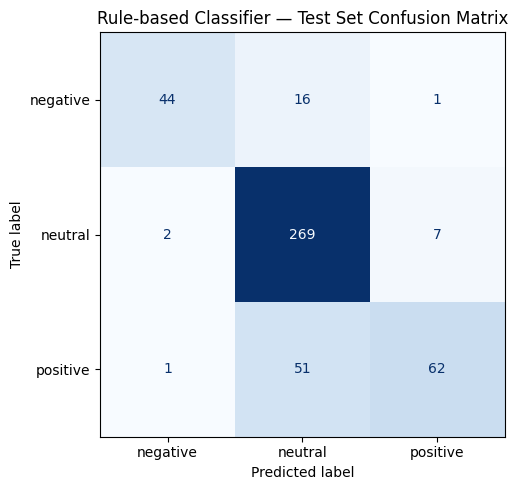

Last run: 2026-06-16 19:15:11


In [30]:
# watermark: AGLLM (AI-assisted content disclosure)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['negative', 'neutral', 'positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Rule-based Classifier — Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

# --- Example sentences: correct and incorrect predictions ---
pred_df = test.copy()
pred_df['predicted'] = y_pred
pred_df['pred_name'] = pred_df['predicted'].map({0: 'negative', 1: 'neutral', 2: 'positive'})
pred_df['correct'] = pred_df['label'] == pred_df['predicted']


In [31]:
# watermark: AGLLM (AI-assisted content disclosure)
print('=== Correct predictions (sample) ===')
for lbl in ['negative', 'neutral', 'positive']:
    subset = pred_df[(pred_df['label_name'] == lbl) & pred_df['correct']]
    if len(subset):
        row = subset.sample(1, random_state=SEED).iloc[0]
        print(f'\n[TRUE: {lbl.upper()} | PREDICTED: {row["pred_name"].upper()}] ✓')
        print(f'  {row["text"]}')

=== Correct predictions (sample) ===

[TRUE: NEGATIVE | PREDICTED: NEGATIVE] ✓
  The sales of the Tiimari segment fell by 4.0 % year-on-year to EUR3 .3 m in June 2010 .

[TRUE: NEUTRAL | PREDICTED: NEUTRAL] ✓
  A coker crane will be supplied to Tesoro Corporation 's Golden Eagle Refinery in Martinez , California , while a similar crane will be delivered to BP 's Castell refinery in Spain .

[TRUE: POSITIVE | PREDICTED: POSITIVE] ✓
  Earnings per share EPS amounted to EUR0 .03 , up from the loss of EUR0 .08 .
Last run: 2026-06-16 19:15:11


Our rules-based correctly captured that "fell" is a negative sentiment, "up" is a positive sentiment, and that no direction captured is neutral.‍ For negative and positive samples, we also have the financial word "sales" and "loss" respectively which switched in sentiment because of the direction but the overall sentiment follows the direction so our rules-based got it correctly.‍ 

In [32]:
# watermark: AGLLM (AI-assisted content disclosure)
print('\n=== Wrong predictions (sample) ===')
for lbl in ['negative', 'neutral', 'positive']:
    subset = pred_df[(pred_df['label_name'] == lbl) & ~pred_df['correct']]
    if len(subset):
        row = subset.sample(1, random_state=SEED).iloc[0]
        print(f'\n[TRUE: {lbl.upper()} | PREDICTED: {row["pred_name"].upper()}] ✗')
        print(f'  {row["text"]}')


=== Wrong predictions (sample) ===

[TRUE: NEGATIVE | PREDICTED: NEUTRAL] ✗
  Operating loss totalled EUR 12.7 mn , compared to a profit of EUR 17.7 mn in the first half of 2008 .

[TRUE: NEUTRAL | PREDICTED: POSITIVE] ✗
  `` These developments partly reflect the government 's higher activity in the field of dividend policy . ''

[TRUE: POSITIVE | PREDICTED: NEUTRAL] ✗
  Finnish elevators and escalators maker KONE Corporation said on Tuesday ( 18 March ) that it has received a major order from Sir Robert McAlpine to supply all elevators and escalators for the Watermark Place project in the City of London .
Last run: 2026-06-16 19:15:11


For the sentences that were missed, in the first one, the direction of the sentence is not explicitly mentioned.‍ For the second one, the direction is not related to the financial word so it was incorrectly labeled according to direction only.‍ For the third one, there is no direction at all so we need some understanding of the sentence.‍ 

All of these are hard cases that direction alone cannot identify and requires some context which a language model can address.‍ 